# Iranian Leaders & Commanders - Verified Portraits

Phase 3 (Iran-Israel Twelve-Day War). This notebook documents the **verified** Iranian leaders/commanders in data/leaders.csv and displays their public, CC BY-SA 4.0 Wikimedia Commons portraits (where a safe local copy exists).

**Ethics & licensing:** only public figures; images are Wikimedia Commons portraits under CC BY-SA 4.0. No identifiable civilians, minors, or unsafe victim photos are used. Each portrait is traced to its source URL and license in data/leaders.csv and exports/image_index.csv.

**Coverage:** 7 senior figures were confirmed killed in the 13 June 2025 Israeli strikes on Tehran (Bagheri, Salami, Hajizadeh, Rashid, Shamkhani, Abbasi, Tehranchi), corroborated by ACLED and HRANA. Ali Khamenei, the Supreme Leader, is recorded as a **death claim (reported killed, unverified, needs_review=true)** pending a reliable cited source - he is held in the review queue, not asserted as a verified casualty.

In [5]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (ROOT.parent / 'data').exists():
    ROOT = ROOT.parent

leaders = pd.read_csv(ROOT / 'data' / 'leaders.csv')
iran = leaders[leaders['phase'] == 'phase3_iran'].copy()
print(f'Iranian leaders/commanders: {len(iran)}')
iran[['leader_id','leader_name','role','organization','death_status','death_date','death_location','verification_status','confidence_level']]

Iranian leaders/commanders: 7


,leader_id,leader_name,role,organization,death_status,death_date,death_location,verification_status,confidence_level
1,LDR-002,Mohammad Bagheri,military commander,Iranian Armed Forces,confirmed dead,2025-06-13,"Tehran, Iran",verified,high
2,LDR-003,Hossein Salami,military commander,Islamic Revolutionary Guard Corps (IRGC),confirmed dead,2025-06-13,"Tehran, Iran",verified,high
3,LDR-004,Amir Ali Hajizadeh,military commander,IRGC Aerospace Force,confirmed dead,2025-06-13,"Tehran, Iran",verified,high
4,LDR-005,Gholam Ali Rashid,military commander,Islamic Revolutionary Guard Corps (IRGC),confirmed dead,2025-06-13,"Tehran, Iran",verified,high
14,LDR-015,Ali Shamkhani,government official,Iranian Armed Forces,confirmed dead,2025-06-13,"Tehran, Iran",verified,high
15,LDR-016,Fereydoon Abbasi,government official,Islamic Revolutionary Guard Corps (IRGC),confirmed dead,2025-06-13,"Tehran, Iran",verified,high
16,LDR-017,Mohammad Mehdi Tehranchi,government official,Islamic Revolutionary Guard Corps (IRGC),confirmed dead,2025-06-13,"Tehran, Iran",verified,high


## Portrait gallery

Displays each leader's local portrait when available. Missing portraits are flagged (no safe local copy / network-restricted).

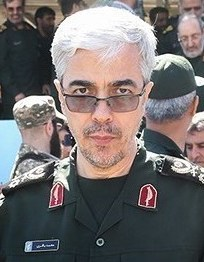

**Mohammad Bagheri** — military commander, Iranian Armed Forces<br>Death: 2025-06-13 (Tehran, Iran)<br>Status: verified / high<br>License: CC BY-SA 4.0 — Wikimedia Commons (Category:Mohammad Bagheri)

------------------------------------------------------------


AttributeError: 'float' object has no attribute 'strip'

In [6]:
def show_leader(row):
    lp = (row.get('image_local_path') or '').strip()
    name = row['leader_name']
    ds = row.get('death_status', '')
    meta = f"**{name}** - {row.get('role','')}, {row.get('organization','')}<br>"
    if ds == 'alive':
        meta += 'Status: ALIVE (living leader)<br>'
    else:
        meta += f"Death status: {ds} ({row.get('death_date','')} {row.get('death_location','')})<br>"
    meta += f"Verification: {row.get('verification_status','')} / {row.get('confidence_level','')}"
    if str(row.get('needs_review','')).lower() in ('true','1'):
        meta += ' [NEEDS REVIEW]<br>'
    meta += f"<br>License: {row.get('image_license','')} - {row.get('image_source','')}"
    if lp and (ROOT / lp).exists():
        return display(Image(filename=str(ROOT / lp), width=180)), display(Markdown(meta))
    return display(Markdown(meta + '<br>*(portrait: not available locally - see image_url)*'))

for _, row in iran.iterrows():
    show_leader(row)
    print('-' * 60)

## Provenance index

Every portrait with its source URL and license (from `exports/image_index.csv`).

In [4]:
idx = pd.read_csv(ROOT / 'exports' / 'image_index.csv')
iran_idx = idx[idx['leader_id'].isin(iran['leader_id'])]
iran_idx[['leader_id','leader_name','image_available','verified_local','image_url','image_license','image_local_path']]

,leader_id,leader_name,image_available,verified_local,image_url,image_license,image_local_path
1,LDR-002,Mohammad Bagheri,True,yes,https://commons.wikimedia.org/wiki/Special:Fil...,CC BY-SA 4.0,data/leaders_photos/LDR-002/LDR-002.jpg
2,LDR-003,Hossein Salami,False,no,https://commons.wikimedia.org/wiki/Special:Fil...,CC BY-SA 4.0,NaN
3,LDR-004,Amir Ali Hajizadeh,True,yes,https://commons.wikimedia.org/wiki/Special:Fil...,CC BY-SA 4.0,data/leaders_photos/LDR-004/LDR-004.jpg
4,LDR-005,Gholam Ali Rashid,False,no,https://commons.wikimedia.org/wiki/Special:Fil...,CC BY-SA 4.0,NaN
14,LDR-015,Ali Shamkhani,True,yes,https://commons.wikimedia.org/wiki/Special:Fil...,CC BY-SA 4.0,data/leaders_photos/LDR-015/LDR-015.jpg
15,LDR-016,Fereydoon Abbasi,True,yes,https://commons.wikimedia.org/wiki/Special:Fil...,CC BY-SA 4.0,data/leaders_photos/LDR-016/LDR-016.jpg
16,LDR-017,Mohammad Mehdi Tehranchi,True,yes,https://commons.wikimedia.org/wiki/Special:Fil...,CC BY-SA 4.0,data/leaders_photos/LDR-017/LDR-017.jpg


## Fetch missing portraits (run in a networked environment)

The following Iranian leaders have `image_available=true` in `data/leaders.csv` but **no local copy** (sandbox is network-restricted). Run `scripts/fetch_leader_photos.py` from a machine with internet access to download them.

- LDR-003 — Hossein Salami
- LDR-005 — Gholam Ali Rashid

```bash
python scripts/fetch_leader_photos.py
python scripts/verify_leader_images.py --remote
```

Until then their `image_available` is correctly marked `false` in `data/leaders.csv` so the dashboard never references a missing file.